<a href="https://colab.research.google.com/github/9569791913harsh-hub/Data-Cleaning-Visualization/blob/main/PredictiveModeling%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
# ============================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [90]:
# Load Breast Cancer dataset
data = load_breast_cancer(as_frame=True)

df = data.frame.copy()

# Convert target values into readable labels
df["target_name"] = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [91]:
# Dataset information
print("Dataset Information:")
print("-" * 50)

df.info()

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area err

In [92]:
# Statistical summary
display(df.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [93]:
# Check missing values
print("Total missing values:", df.isnull().sum().sum())

# Check duplicate records
print("Total duplicate rows:", df.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


In [94]:
print("Target Distribution:")
print(df["target_name"].value_counts())

Target Distribution:
target_name
Benign       357
Malignant    212
Name: count, dtype: int64


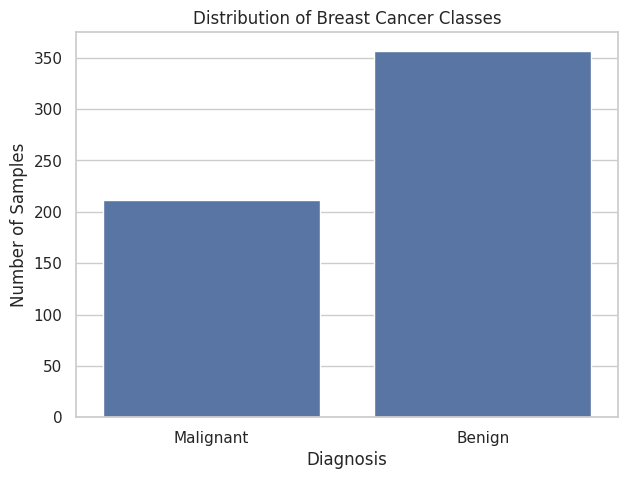

In [95]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target_name"
)

plt.title("Distribution of Breast Cancer Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

In [96]:
# Features
X = df.drop(columns=["target", "target_name"])

# Target
y = df["target"]

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

Number of features: 30
Number of samples: 569


In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [98]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Models created successfully!")

Models created successfully!


In [99]:
results = []
trained_models = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = model

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create comparison dataframe
results_df = pd.DataFrame(results)

# Sort by F1 Score
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
1,Random Forest,0.9474,0.9583,0.9583,0.9583
2,Decision Tree,0.9211,0.9565,0.9167,0.9362


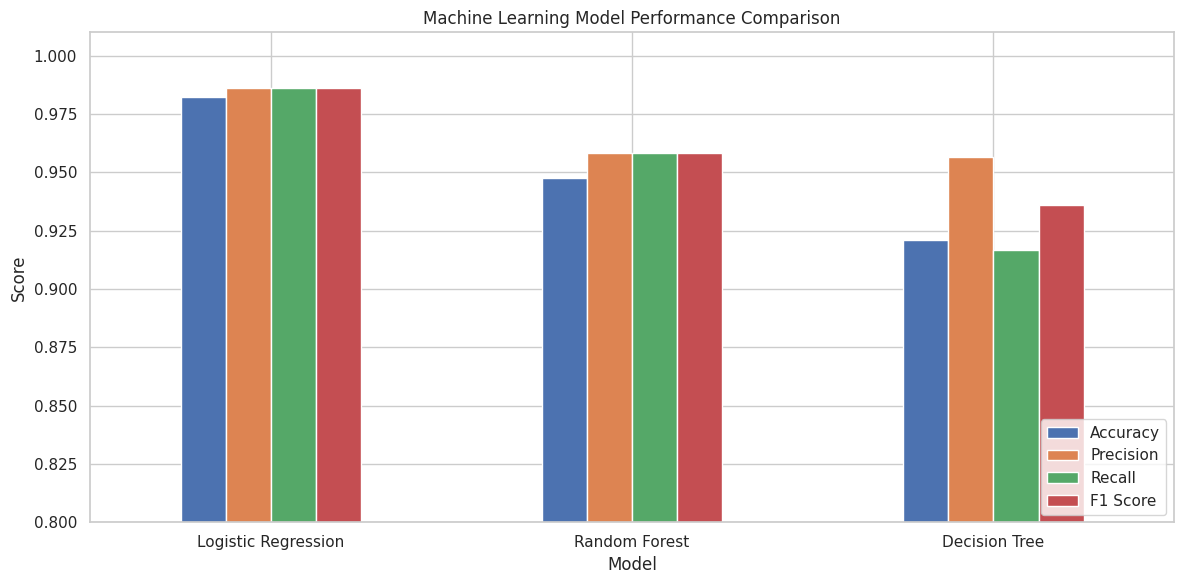

In [100]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.80, 1.01)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

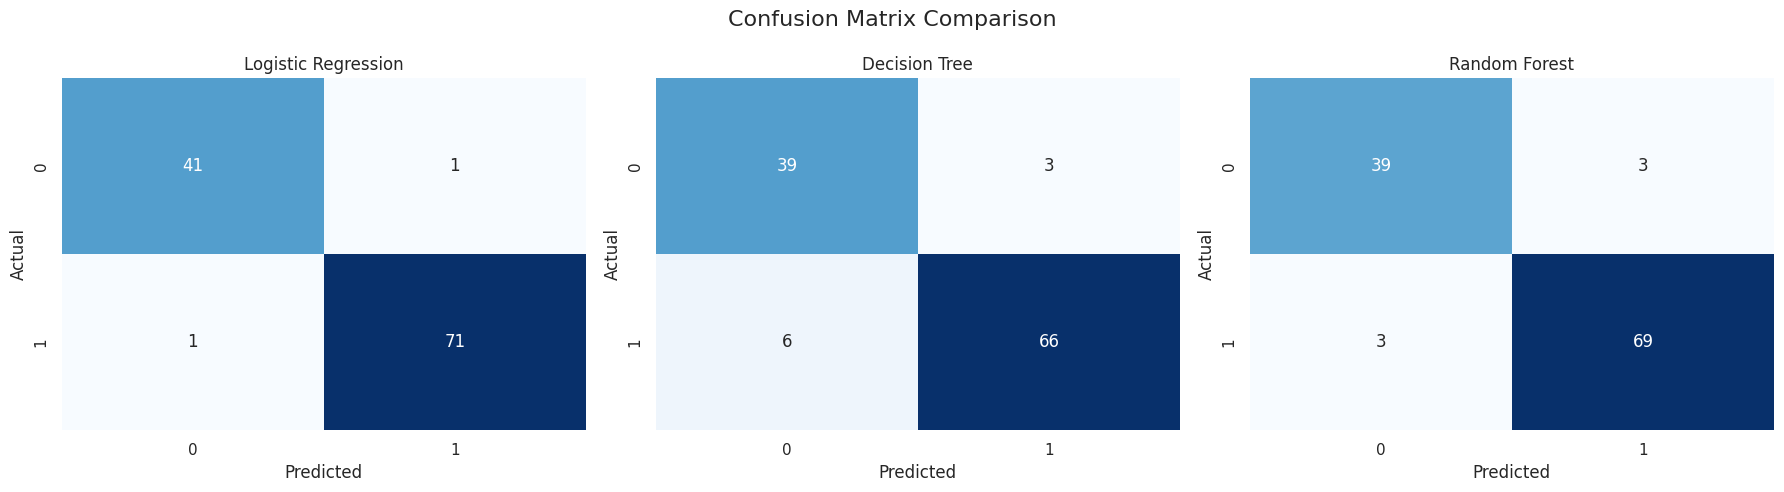

In [101]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (name, model) in zip(
    axes,
    trained_models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()

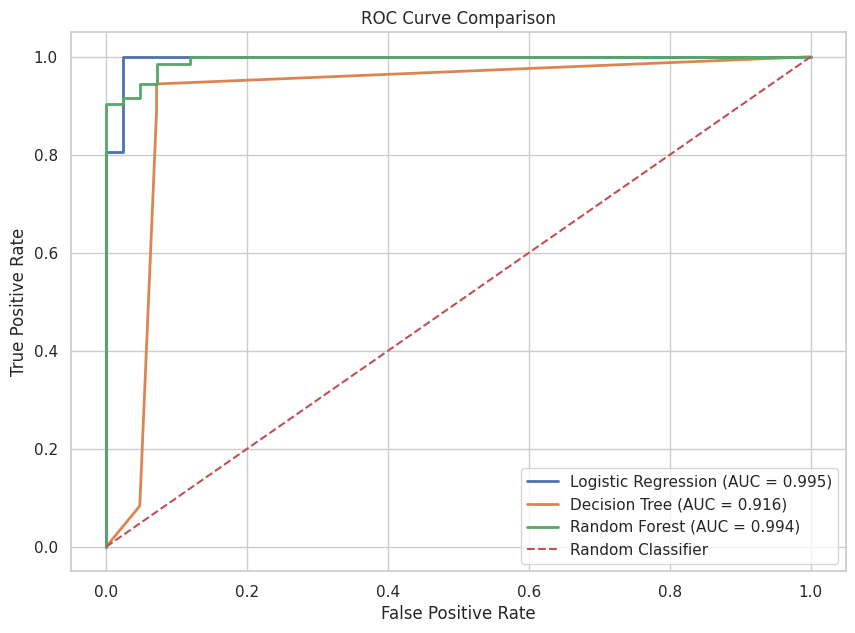

In [102]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    # Probability for positive class
    y_probability = model.predict_proba(X_test)[:, 1]

    # Calculate ROC
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [103]:
# Select best model based on F1 Score
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("=" * 60)

best_predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

Best Model: Logistic Regression
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [104]:
random_forest = trained_models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
22,worst perimeter,0.137344
23,worst area,0.137312
27,worst concave points,0.115502
7,mean concave points,0.091774
20,worst radius,0.084111
0,mean radius,0.062741
2,mean perimeter,0.049680
6,mean concavity,0.044142
3,mean area,0.040508
26,worst concavity,0.034837


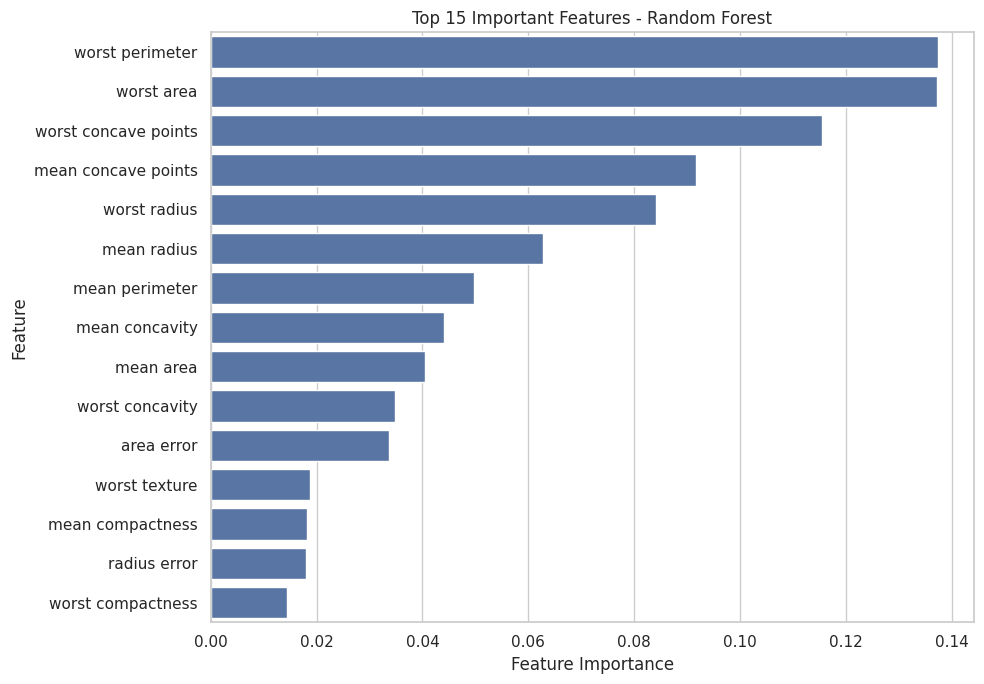

In [105]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features - Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [106]:
# Take one sample from the test dataset
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]

if prediction == 0:
    result = "Malignant"
else:
    result = "Benign"

print("Predicted Diagnosis:", result)

Predicted Diagnosis: Malignant


In [107]:
print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)

print("\nModel Performance:")
display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}"
    })
)

print("\nBest Performing Model:")
print(best_model_name)

print("\nProject completed successfully!")

FINAL PROJECT RESULTS

Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,98.25%,98.61%,98.61%,98.61%
1,Random Forest,94.74%,95.83%,95.83%,95.83%
2,Decision Tree,92.11%,95.65%,91.67%,93.62%



Best Performing Model:
Logistic Regression

Project completed successfully!


In [108]:
# Create results directory
import os

os.makedirs("results", exist_ok=True)

# Save model comparison
results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [109]:
from google.colab import files

files.download("results/model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>